# Sewer Atlas Sandbox

This notebook was created for your selected sandbox datasets.

## Selected Datasets

- `cdc-facility-virus-levels`: Wastewater Viral Activity Levels
- `plant-population-statistics`: Plant Population Statistics
- `plant-land-cover-statistics`: Plant Land Use / Land Cover Statistics

In [ ]:
import matplotlib as plt
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

[{'id': 'cdc-facility-virus-levels',
  'name': 'Wastewater Viral Activity Levels',
  'category': 'Wastewater Surveillance',
  'geometry_type': 'table',
  'formats': ['csv'],
  'row_count': None,
  'source': {'kind': 'cdc_facility_virus_levels'},
  'columns': ['id',
   'facility_id',
   'sewershed_id',
   'virus',
   'sample_collect_date',
   'pcr_target_avg_conc',
   'pcr_target_units',
   'source_updated_at',
   'source_site',
   'source_state',
   'created_at',
   'updated_at']},
 {'id': 'plant-population-statistics',
  'name': 'Plant Population Statistics',
  'category': 'Plant Dashboard Statistics',
  'geometry_type': 'table',
  'formats': ['csv'],
  'row_count': None,
  'source': {'kind': 'facility_spatial_stats',
   'metric_keys': ['population',
    'population_children',
    'population_youth',
    'population_working_age',
    'population_elderly']},
  'columns': ['id',
   'plant_id',
   'metric_key',
   'label',
   'value',
   'unit',
   'aggregation',
   'card_key',
   'metad

## Load A Dataset

In [2]:
df = datasets.load("cdc-facility-virus-levels")
df.head()

,created_at,facility_id,id,pcr_target_avg_conc,pcr_target_units,sample_collect_date,sewershed_id,source_site,source_state,source_updated_at,updated_at,virus
0,2026-05-22T01:13:55.220601+00:00,512cb36c-328e-488c-ba06-58840c93601f,393612,3120.0,copies/l wastewater,2020-08-23,2154,2154,wi,2026-08-14T12:32:00+00:00,2026-08-17T00:03:37.749176+00:00,covid
1,2026-05-22T01:13:55.220601+00:00,e6b99141-c050-4f23-a65d-be3b950418a6,393611,4464.0,copies/l wastewater,2020-08-23,2108,2108,wi,2026-08-14T12:32:00+00:00,2026-08-17T00:03:37.749199+00:00,covid
2,2026-05-22T01:13:55.220601+00:00,eac70dd3-725c-44bc-9f32-6ed5927fe7a5,393615,2524.8,copies/l wastewater,2020-08-24,2107,2107,wi,2026-08-14T12:32:00+00:00,2026-08-17T00:03:37.749212+00:00,covid
3,2026-05-22T01:13:55.220601+00:00,e6b99141-c050-4f23-a65d-be3b950418a6,393614,4732.8,copies/l wastewater,2020-08-24,2108,2108,wi,2026-08-14T12:32:00+00:00,2026-08-17T00:03:37.749228+00:00,covid
4,2026-05-22T01:13:55.220601+00:00,512cb36c-328e-488c-ba06-58840c93601f,393613,1948.8,copies/l wastewater,2020-08-24,2154,2154,wi,2026-08-14T12:32:00+00:00,2026-08-17T00:03:37.74922+00:00,covid


## Load All Rows

In [3]:
# Use this for larger datasets when you want every row.
all_rows = datasets.load_all("cdc-facility-virus-levels")
all_rows.head()

,created_at,facility_id,id,pcr_target_avg_conc,pcr_target_units,sample_collect_date,sewershed_id,source_site,source_state,source_updated_at,updated_at,virus
0,2026-05-22T01:13:55.220601+00:00,e6b99141-c050-4f23-a65d-be3b950418a6,393611,4464.0,copies/l wastewater,2020-08-23,2108,2108,wi,2026-08-14T12:32:00+00:00,2026-08-17T00:03:37.749199+00:00,covid
1,2026-05-22T01:13:55.220601+00:00,512cb36c-328e-488c-ba06-58840c93601f,393612,3120.0,copies/l wastewater,2020-08-23,2154,2154,wi,2026-08-14T12:32:00+00:00,2026-08-17T00:03:37.749176+00:00,covid
2,2026-05-22T01:13:55.220601+00:00,512cb36c-328e-488c-ba06-58840c93601f,393613,1948.8,copies/l wastewater,2020-08-24,2154,2154,wi,2026-08-14T12:32:00+00:00,2026-08-17T00:03:37.74922+00:00,covid
3,2026-05-22T01:13:55.220601+00:00,e6b99141-c050-4f23-a65d-be3b950418a6,393614,4732.8,copies/l wastewater,2020-08-24,2108,2108,wi,2026-08-14T12:32:00+00:00,2026-08-17T00:03:37.749228+00:00,covid
4,2026-05-22T01:13:55.220601+00:00,eac70dd3-725c-44bc-9f32-6ed5927fe7a5,393615,2524.8,copies/l wastewater,2020-08-24,2107,2107,wi,2026-08-14T12:32:00+00:00,2026-08-17T00:03:37.749212+00:00,covid


In [4]:
pop = datasets.load("plant-population-statistics")
lulc = datasets.load("plant-land-cover-statistics")
vir = datasets.load("cdc-facility-virus-levels")

In [5]:
lulc_ids = set(vir['facility_id'].astype(str).str.strip())
vir_ids = set(pop['plant_id'].astype(str).str.strip())
pop_ids = set(lulc['plant_id'].astype(str).str.strip())
matching_ids = lulc_ids.intersection(vir_ids)
total_matches = matching_ids.intersection(pop_ids)

In [6]:
filtered_vir = vir[vir['facility_id'].isin(total_matches)]
filtered_pop = pop[pop['plant_id'].isin(total_matches)]
filtered_lulc = lulc[lulc['plant_id'].isin(total_matches)]

In [7]:
#calculating the mean viral amount for each facility
mean_virus = dict()
for id in total_matches:
    virus_values = vir.loc[vir['facility_id'] == id]
    mean_virus[id] = virus_values['pcr_target_avg_conc'].mean()

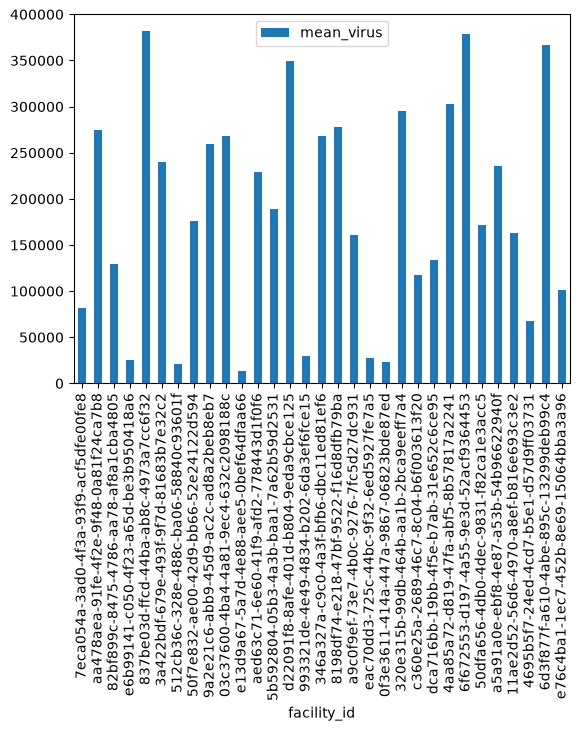

In [20]:
#make a pandas df
mv = pd.DataFrame(
    mean_virus.items(),
    columns=['facility_id','mean_virus']
)
mv.plot.bar(x= 'facility_id', y= 'mean_virus')
plt.savefig("virus_per_facility.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
#seperate the population data
pop_table = pop.pivot_table(
    index='plant_id',
    columns='label',
    values='value',
    aggfunc='first'
).reset_index()
print(pop_table.head())
print(pop_table.shape)

#seperate the lulc data
lulc_table = lulc.pivot_table(
    index='plant_id',
    columns='label',
    values='value',
    aggfunc='first',
).reset_index()
print(lulc_table.head())
print(lulc_table.shape)

static_data = pd.merge(
    pop_table,
    lulc_table,
    on=['plant_id'],
    how="inner"
)
print(static_data.head())
print(static_data.shape)

label                              plant_id  Children (0-14)  Elderly (65+)  \
0      00a0b52d-51da-4e35-acc2-6623fadd3979             8465          10986   
1      0142ec61-07de-4c09-9880-eb48a9e447fd             6527           8203   
2      02d39649-b5c0-48bb-b688-0dadafa991d7            20964          19861   
3      03c37600-4ba4-4a81-9ec4-632c2098188c            10723          12332   
4      03cf5439-53ef-43c1-8cd6-f40c7ac50451             6289           5656   

label  Population  Working Age (25-64)  Youth (15-24)  
0           62090                27480          14904  
1           42425                17434          11225  
2          127828                53962          36720  
3           73115                32729          17955  
4           49812                17267          20462  
(135, 6)
label                              plant_id  Agriculture  Barren Land  \
0      00a0b52d-51da-4e35-acc2-6623fadd3979         22.8          0.0   
1      0142ec61-07de-4c09-9880-eb4

In [11]:
filtered_data = mv.merge(
    static_data,
    right_on=['plant_id'],
    left_on=['facility_id'],
    how='inner'
)
filtered_data = filtered_data.drop(columns=['plant_id'])
print(filtered_data.head())
print(filtered_data.shape)

                            facility_id     mean_virus  Children (0-14)  \
0  7eca054a-3ad0-4f3a-93f9-acf5dfe00fe8   81723.280804             2490   
1  aa478aea-91fe-4f2e-9f48-0a81f24ca7b8  274554.255252             1229   
2  82bf899c-8475-4786-aa78-af8a1cba4805  129497.543298              463   
3  e6b99141-c050-4f23-a65d-be3b950418a6   25139.950522            35453   
4  837be03d-ffcd-44ba-ab8c-4973a7cc6f32  381524.329962             9235   

   Elderly (65+)  Population  Working Age (25-64)  Youth (15-24)  Agriculture  \
0           3920       18971                 8221           4156         23.7   
1           2075        9657                 4261           2149         14.7   
2            640        3461                 1498            743         43.4   
3          37187      241203               107794          61593         40.6   
4          12075       75988                33610          19426         20.9   

   Barren Land  Built-up  Forest  Grassland  Water  Wetlands  

<Axes: >

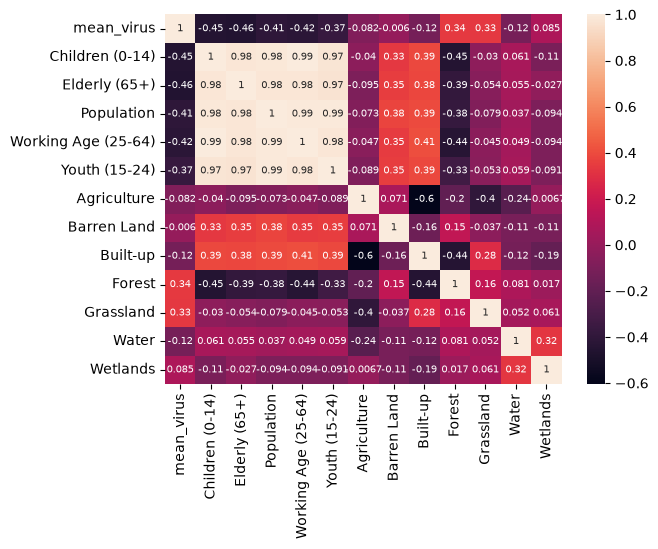

In [21]:
#Correlation Matrix
correlation = filtered_data.corr(numeric_only=True, method='spearman')
plt.savefig("sewer_atlas_correlation.png", dpi=300, bbox_inches="tight")
sns.heatmap(correlation, annot=True, annot_kws={'fontsize': 7})

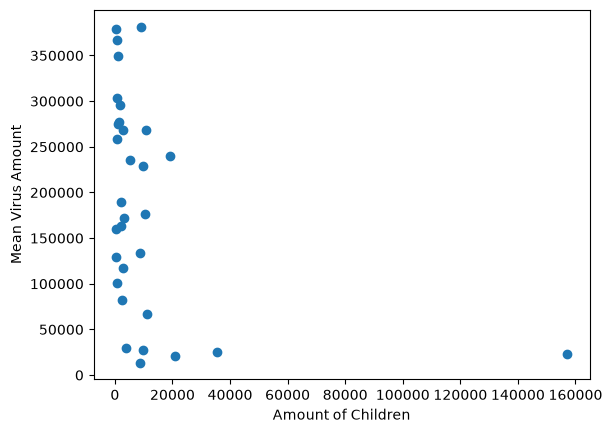

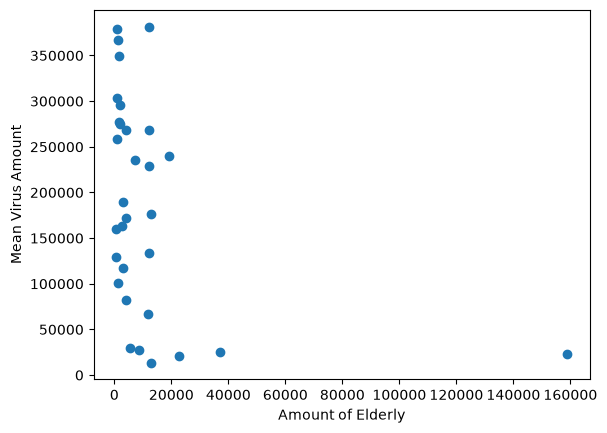

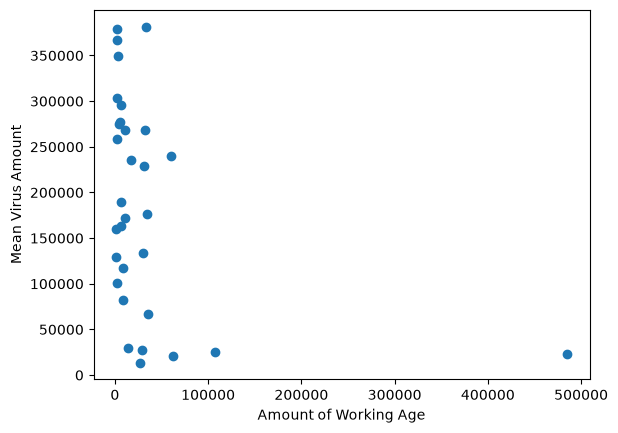

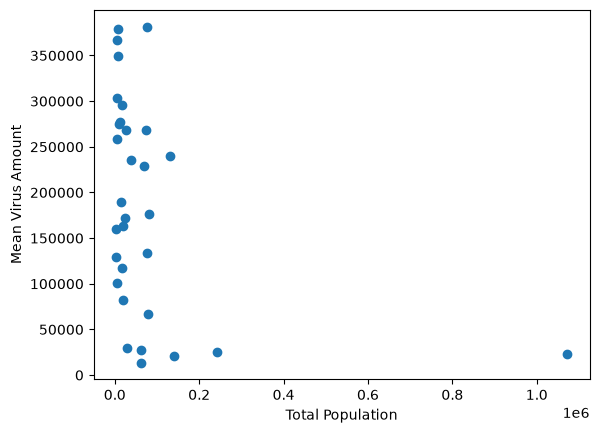

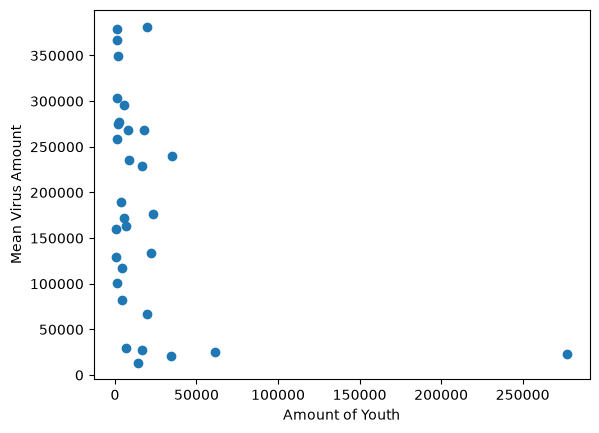

In [22]:
#Highest correlation variables: Children, Elderly, Population, Working Age, Youth,
plt.scatter(filtered_data['Children (0-14)'], filtered_data['mean_virus'])
plt.xlabel('Amount of Children')
plt.ylabel('Mean Virus Amount')
plt.savefig("children_by_virus.png", dpi=300, bbox_inches="tight")
plt.show()
plt.scatter(filtered_data['Elderly (65+)'], filtered_data['mean_virus'])
plt.xlabel('Amount of Elderly')
plt.ylabel('Mean Virus Amount')
plt.savefig("elderly_by_virus.png", dpi=300, bbox_inches="tight")
plt.show()
plt.scatter(filtered_data['Working Age (25-64)'], filtered_data['mean_virus'])
plt.xlabel('Amount of Working Age')
plt.ylabel('Mean Virus Amount')
plt.savefig("working_by_virus.png", dpi=300, bbox_inches="tight")
plt.show()
plt.scatter(filtered_data['Population'], filtered_data['mean_virus'])
plt.xlabel('Total Population')
plt.ylabel('Mean Virus Amount')
plt.savefig("population_by_virus.png", dpi=300, bbox_inches="tight")
plt.show()
plt.scatter(filtered_data['Youth (15-24)'], filtered_data['mean_virus'])
plt.xlabel('Amount of Youth')
plt.ylabel('Mean Virus Amount')
plt.savefig("youth_by_virus.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
#Create Linear Regression Model
X = filtered_data[['Children (0-14)','Elderly (65+)','Working Age (25-64)','Youth (15-24)']]
y = filtered_data['mean_virus']
model = LinearRegression()
model.fit(X,y)

print(model.score(X,y))

0.3480481406607955


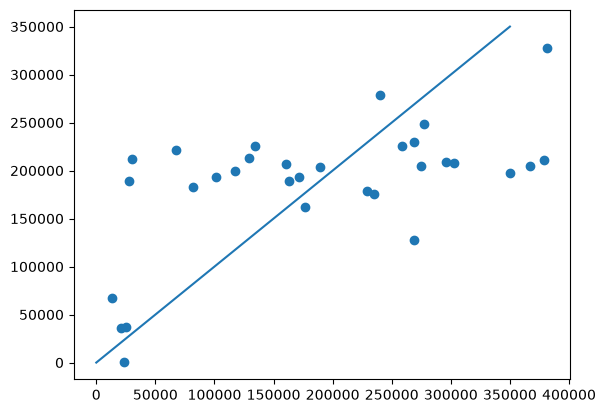

In [23]:
pred = model.predict(X)
plt.scatter(y,pred)
plt.plot([0,350000],[0,350000])
plt.savefig("actual_by_predicted.png", dpi=300, bbox_inches="tight")
plt.show()